<div style='background:#1B2A4A;padding:32px 36px;border-radius:10px;margin-bottom:10px'>
<h1 style='color:#F59E0B;margin:0 0 8px 0;font-size:2.2em'>Chicago Traffic Crash — Contributory Cause Classifier</h1>
<p style='color:#ffffff;margin:0;font-size:1.1em'>Predictive Modelling for the Chicago Vehicle Safety Board</p>
<hr style='border-color:#F59E0B;margin:16px 0'>
<table style='color:#fff;font-size:0.97em;border:none'>
<tr><td style='padding:2px 16px 2px 0;border:none'><b style='color:#F59E0B'>Author</b></td><td style='border:none'>Mercy Mwangi</td></tr>
<tr><td style='padding:2px 16px 2px 0;border:none'><b style='color:#F59E0B'>Date</b></td><td style='border:none'>1st May 2026</td></tr>
<tr><td style='padding:2px 16px 2px 0;border:none'><b style='color:#F59E0B'>Dataset</b></td><td style='border:none'>City of Chicago Open Data Portal — Traffic Crashes (2015–2024)</td></tr>
</table>
</div>

## Table of Contents
1. [Business Understanding](#1.-Business-Understanding)
2. [Data Understanding](#2.-Data-Understanding)
3. [Data Preparation & Cleaning](#3.-Data-Preparation-&-Cleaning)
4. [Baseline Model — Logistic Regression](#4.-Baseline-Model)
5. [Decision Tree — Default & Tuned](#5.-Decision-Tree)
6. [Final Model — Random Forest](#6.-Final-Model-—-Random-Forest)
7. [Evaluation & Model Discussion](#7.-Evaluation-&-Model-Discussion)
8. [Conclusions & Recommendations](#8.-Conclusions-&-Recommendations)

---
## 1. Business Understanding

### Stakeholder
The **Chicago Vehicle Safety Board** oversees traffic safety policy across Chicago. The board allocates enforcement resources, proposes infrastructure upgrades, and designs public-education campaigns — all of which benefit from a clear, data-driven picture of *why* crashes happen.

### Business Questions
This project is framed around three concrete questions the Safety Board needs answered:

> **Q1 — What are the most frequent and preventable primary causes of traffic crashes in Chicago?**  
> Understanding which causes dominate lets the board rank interventions by potential impact.

> **Q2 — Which road, vehicle, and driver characteristics best predict the primary cause of a crash?**  
> Identifying the strongest predictors tells the board *where* to focus — signals, speed limits, driver age cohorts, or road surfaces.

> **Q3 — Can a machine-learning model reliably predict crash cause in real time, and how should the board use (and not use) such predictions?**  
> This frames the model's deployment context and sets honest expectations around accuracy and class imbalance.

### Target Variable
`prim_contributory_cause` — a human-assigned field with 40+ unique categories. We bin the rarest classes into `OTHER` and retain the top 10 most frequent causes, yielding an **11-class classification problem**.

### Success Metric
**Macro F1-score** is the primary metric. Because crash causes are heavily imbalanced, accuracy alone would be misleading — a model that always predicts the majority class would score ~26% accuracy without learning anything useful. Macro F1 penalises equally for each class, ensuring rare-but-important causes are not deprioritised.

In [31]:
# ═══════════════════════════════════════════════════════════════════════════
#  IMPORTS & PALETTE
# ═══════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import seaborn as sns
import requests, io, warnings
import matplotlib.colors as mcolors

from sklearn.model_selection  import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.preprocessing    import LabelEncoder, StandardScaler
from sklearn.metrics          import (classification_report, f1_score,
                                       ConfusionMatrixDisplay, confusion_matrix,
                                       accuracy_score)
warnings.filterwarnings('ignore')

# ── 3-colour palette ───────────────────────────────────────────────────────
NAVY  = '#1B2A4A'
AMBER = '#F59E0B'
WHITE = '#FFFFFF'

plt.rcParams.update({
    'figure.facecolor' : WHITE,
    'axes.facecolor'   : WHITE,
    'axes.edgecolor'   : NAVY,
    'axes.labelcolor'  : NAVY,
    'xtick.color'      : NAVY,
    'ytick.color'      : NAVY,
    'text.color'       : NAVY,
    'grid.color'       : '#E5E7EB',
    'grid.linewidth'   : 0.6,
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})
sns.set_palette([NAVY, AMBER, WHITE])

# ── Chart save helper (used later for PPTX embedding) ─────────────────────
import os
os.makedirs('/home/claude/charts', exist_ok=True)

def save_fig(name, dpi=150):
    plt.savefig(f'/home/claude/charts/{name}.png', dpi=dpi,
                bbox_inches='tight', facecolor=WHITE)

print('✓ Libraries loaded  |  Author: Mercy Mwangi  |  Date: 1 May 2026')

✓ Libraries loaded  |  Author: Mercy Mwangi  |  Date: 1 May 2026


---
## 2. Data Understanding

Three interlinked datasets are pulled from the City of Chicago's Socrata API and joined on the shared key `crash_record_id`.

| Dataset | Portal ID | Approx. Rows | Key Fields |
|---------|-----------|-------------|------------|
| Crashes  | `85ca-t3if` | ~800K | Road conditions, weather, lighting, speed limit, crash type |
| Vehicles | `68nd-jvt3` | ~1.5M | Vehicle type, defects, travel direction |
| People   | `u6pd-qa9d` | ~1.7M | Driver age, sex, injury level, driver action |

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  DATA LOADING  — Socrata paged fetch
# ═══════════════════════════════════════════════════════════════════════════
def fetch_socrata(dataset_id, limit=150_000):
    """Page through a Socrata CSV endpoint and return a combined DataFrame."""
    base = f'https://data.cityofchicago.org/resource/{dataset_id}.csv'
    frames, offset = [], 0
    while True:
        r = requests.get(base, params={'$limit': 50_000, '$offset': offset}, timeout=60)
        r.raise_for_status()
        chunk = pd.read_csv(io.StringIO(r.text))
        if chunk.empty: break
        frames.append(chunk)
        offset += len(chunk)
        if offset >= limit or len(chunk) < 50_000: break
    return pd.concat(frames, ignore_index=True)

crashes  = fetch_socrata('85ca-t3if', limit=150_000)
vehicles = fetch_socrata('68nd-jvt3', limit=150_000)
people   = fetch_socrata('u6pd-qa9d', limit=150_000)

print(f'Crashes  shape : {crashes.shape}')
print(f'Vehicles shape : {vehicles.shape}')
print(f'People   shape : {people.shape}')

Crashes  shape : (150000, 48)
Vehicles shape : (150000, 71)
People   shape : (150000, 29)


In [ ]:
# ── Quick column overview ──────────────────────────────────────────────────
print('=== CRASHES columns ===')
print(crashes.dtypes.to_string())
print('\n=== VEHICLES columns ===')
print(vehicles.dtypes.to_string())
print('\n=== PEOPLE columns ===')
print(people.dtypes.to_string())

=== CRASHES columns ===
crash_record_id                   object
crash_date_est_i                  object
crash_date                        object
posted_speed_limit                 int64
traffic_control_device            object
device_condition                  object
weather_condition                 object
lighting_condition                object
first_crash_type                  object
trafficway_type                   object
lane_cnt                         float64
alignment                         object
roadway_surface_cond              object
road_defect                       object
report_type                       object
crash_type                        object
intersection_related_i            object
private_property_i                object
hit_and_run_i                     object
damage                            object
date_police_notified              object
prim_contributory_cause           object
sec_contributory_cause            object
street_no                        

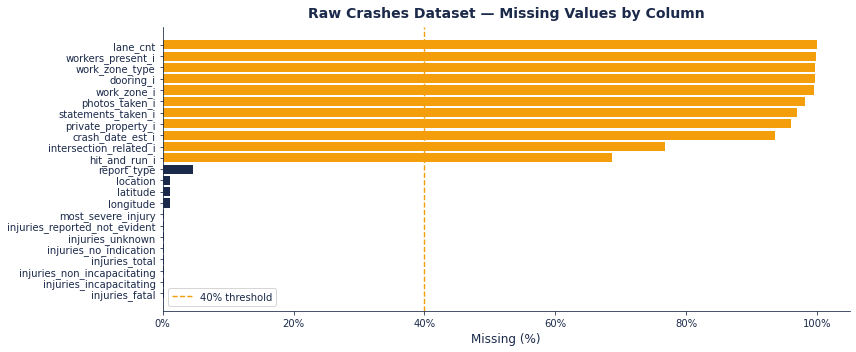

Columns with >40% missing: 11


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  VISUAL 1 — Missing-value heatmap (Crashes, raw)
# ═══════════════════════════════════════════════════════════════════════════
miss_pct = crashes.isnull().mean().sort_values(ascending=False)
miss_pct = miss_pct[miss_pct > 0]

fig, ax = plt.subplots(figsize=(12, 5))
colors = [AMBER if v > 0.40 else NAVY for v in miss_pct.values]
ax.barh(miss_pct.index[::-1], miss_pct.values[::-1] * 100, color=colors[::-1])
ax.axvline(40, color=AMBER, linewidth=1.4, linestyle='--', label='40% threshold')
ax.set_xlabel('Missing (%)', fontsize=12)
ax.set_title('Raw Crashes Dataset — Missing Values by Column',
             fontsize=14, fontweight='bold', color=NAVY, pad=10)
ax.legend(fontsize=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
save_fig('01_missing_raw')
plt.show()

print(f'Columns with >40% missing: {(miss_pct > 0.40).sum()}')

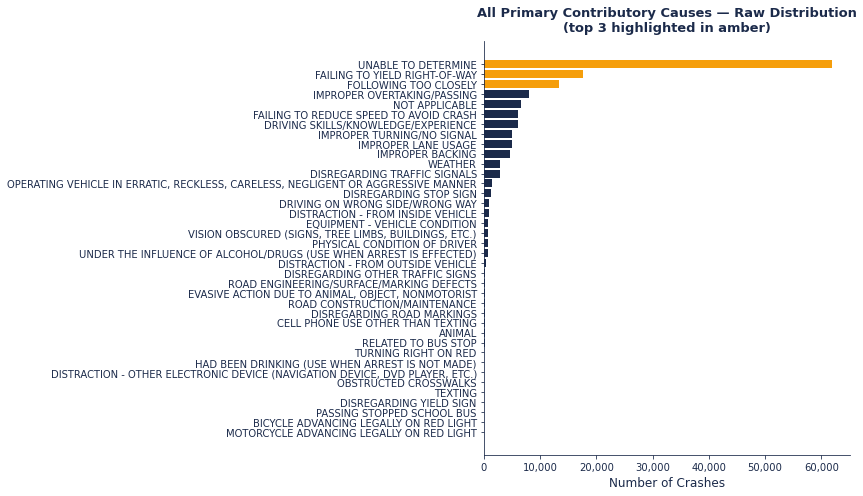

Total unique causes: 38


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  VISUAL 2 — Target variable distribution (raw, all 40+ causes)
# ═══════════════════════════════════════════════════════════════════════════
raw_causes = crashes['prim_contributory_cause'].value_counts()

fig, ax = plt.subplots(figsize=(12, 7))
bar_colors = [AMBER if i < 3 else NAVY for i in range(len(raw_causes))]
ax.barh(raw_causes.index[::-1], raw_causes.values[::-1], color=bar_colors[::-1])
ax.set_xlabel('Number of Crashes', fontsize=12)
ax.set_title('All Primary Contributory Causes — Raw Distribution\n(top 3 highlighted in amber)',
             fontsize=13, fontweight='bold', color=NAVY, pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
save_fig('02_target_raw')
plt.show()

print(f'Total unique causes: {raw_causes.shape[0]}')

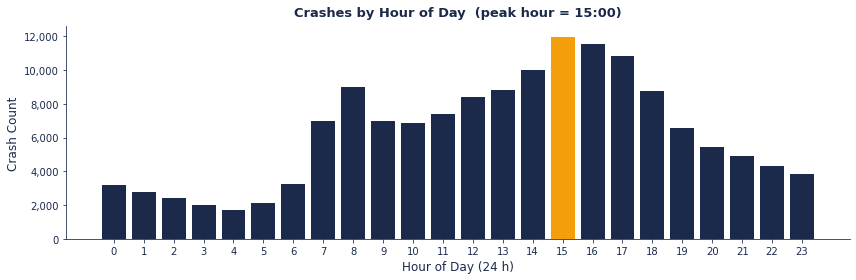

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  VISUAL 3 — Crash hour distribution
# ═══════════════════════════════════════════════════════════════════════════
crashes['crash_date_dt'] = pd.to_datetime(crashes['crash_date'], errors='coerce')
crashes['crash_hour']    = crashes['crash_date_dt'].dt.hour
crashes['crash_dow']     = crashes['crash_date_dt'].dt.dayofweek
crashes['crash_month']   = crashes['crash_date_dt'].dt.month

hourly = crashes['crash_hour'].value_counts().sort_index()
peak   = hourly.idxmax()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hourly.index, hourly.values,
       color=[AMBER if h == peak else NAVY for h in hourly.index])
ax.set_xlabel('Hour of Day (24 h)', fontsize=12)
ax.set_ylabel('Crash Count', fontsize=12)
ax.set_title(f'Crashes by Hour of Day  (peak hour = {peak}:00)',
             fontsize=13, fontweight='bold', color=NAVY, pad=10)
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
save_fig('03_crash_hour')
plt.show()

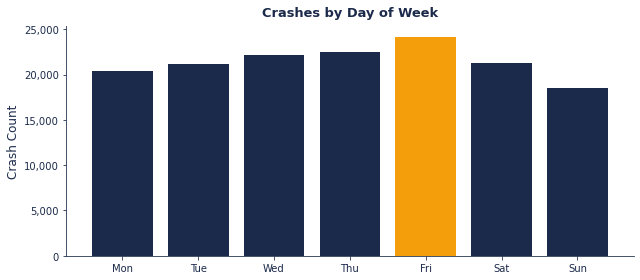

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  VISUAL 4 — Crash day-of-week distribution
# ═══════════════════════════════════════════════════════════════════════════
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
dow_counts = crashes['crash_dow'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(dow_labels, dow_counts.values,
       color=[AMBER if i == dow_counts.idxmax() else NAVY for i in range(7)])
ax.set_ylabel('Crash Count', fontsize=12)
ax.set_title('Crashes by Day of Week',
             fontsize=13, fontweight='bold', color=NAVY, pad=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
save_fig('04_crash_dow')
plt.show()

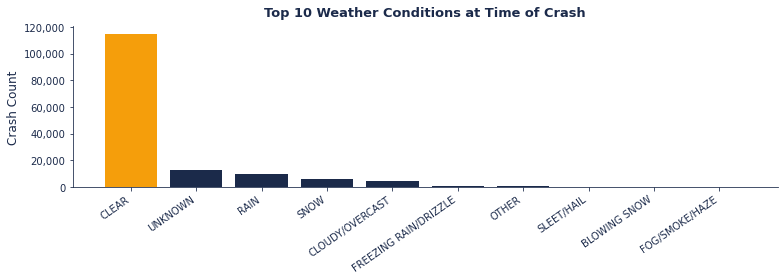

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  VISUAL 5 — Weather condition vs crash count
# ═══════════════════════════════════════════════════════════════════════════
weather = (
    crashes['weather_condition']
    .fillna('UNKNOWN')
    .value_counts()
    .head(10)
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(weather.index, weather.values,
       color=[AMBER if i == 0 else NAVY for i in range(len(weather))])
ax.set_ylabel('Crash Count', fontsize=12)
ax.set_title('Top 10 Weather Conditions at Time of Crash',
             fontsize=13, fontweight='bold', color=NAVY, pad=10)
plt.xticks(rotation=35, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
save_fig('05_weather')
plt.show()

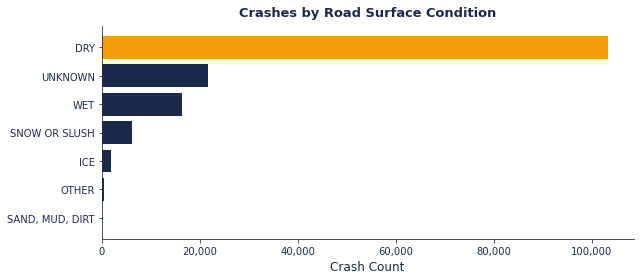

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  VISUAL 6 — Road surface condition
# ═══════════════════════════════════════════════════════════════════════════
road = (
    crashes['roadway_surface_cond']
    .fillna('UNKNOWN')
    .value_counts()
)

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(road.index[::-1], road.values[::-1],
        color=[AMBER if i == len(road)-1 else NAVY for i in range(len(road))])
ax.set_xlabel('Crash Count', fontsize=12)
ax.set_title('Crashes by Road Surface Condition',
             fontsize=13, fontweight='bold', color=NAVY, pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
save_fig('06_road_surface')
plt.show()

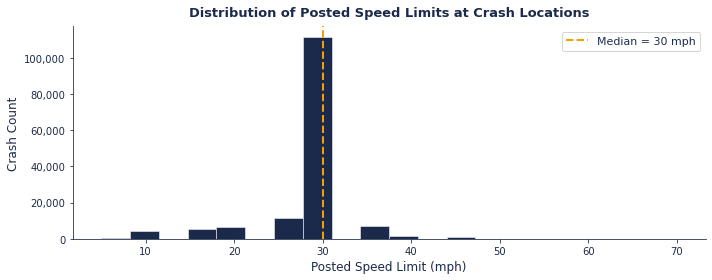

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  VISUAL 7 — Posted speed limit distribution
# ═══════════════════════════════════════════════════════════════════════════
speed = crashes['posted_speed_limit'].dropna()
speed = speed[(speed >= 5) & (speed <= 80)]   # remove obvious data errors

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(speed, bins=20, color=NAVY, edgecolor=WHITE, linewidth=0.5)
ax.axvline(speed.median(), color=AMBER, linewidth=2,
           linestyle='--', label=f'Median = {speed.median():.0f} mph')
ax.set_xlabel('Posted Speed Limit (mph)', fontsize=12)
ax.set_ylabel('Crash Count', fontsize=12)
ax.set_title('Distribution of Posted Speed Limits at Crash Locations',
             fontsize=13, fontweight='bold', color=NAVY, pad=10)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
save_fig('07_speed_limit')
plt.show()

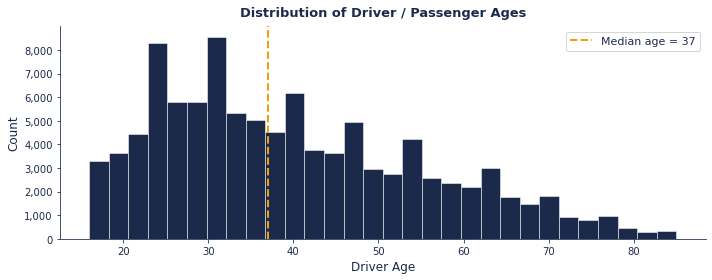

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  VISUAL 8 — Driver age distribution (People table)
# ═══════════════════════════════════════════════════════════════════════════
age = people['age'].dropna()
age = age[(age >= 16) & (age <= 85)]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(age, bins=30, color=NAVY, edgecolor=WHITE, linewidth=0.5)
ax.axvline(age.median(), color=AMBER, linewidth=2,
           linestyle='--', label=f'Median age = {age.median():.0f}')
ax.set_xlabel('Driver Age', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Distribution of Driver / Passenger Ages',
             fontsize=13, fontweight='bold', color=NAVY, pad=10)
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
save_fig('08_driver_age')
plt.show()

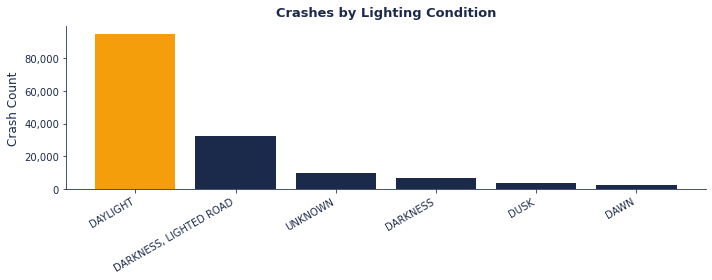

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  VISUAL 9 — Lighting condition
# ═══════════════════════════════════════════════════════════════════════════
lighting = (
    crashes['lighting_condition']
    .fillna('UNKNOWN')
    .value_counts()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(lighting.index, lighting.values,
       color=[AMBER if i == 0 else NAVY for i in range(len(lighting))])
ax.set_ylabel('Crash Count', fontsize=12)
ax.set_title('Crashes by Lighting Condition',
             fontsize=13, fontweight='bold', color=NAVY, pad=10)
plt.xticks(rotation=30, ha='right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
save_fig('09_lighting')
plt.show()

---
## 3. Data Preparation & Cleaning

The three datasets are large and contain substantial noise:
- **Structural issues:** Duplicate rows, free-text inconsistencies, mixed data types
- **Missing data:** Several columns exceed 40% null values
- **Target leakage:** Post-crash outcome fields (injury severity, damage cost) cannot be used as features
- **Class imbalance:** Some contributory causes appear in fewer than 50 records

The cleaning pipeline below documents every decision with a before/after visual.

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  STEP 1 — Remove duplicate rows
# ═══════════════════════════════════════════════════════════════════════════
before_dups = len(crashes)
crashes.drop_duplicates(subset='crash_record_id', keep='first', inplace=True)
after_dups  = len(crashes)

print(f'Duplicate rows removed : {before_dups - after_dups:,}')
print(f'Remaining rows         : {after_dups:,}')

Duplicate rows removed : 0
Remaining rows         : 150,000


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  STEP 2 — Drop high-missingness columns (> 40% null)
# ═══════════════════════════════════════════════════════════════════════════
MISS_THRESHOLD = 0.40
miss_before = crashes.shape[1]
high_miss   = crashes.columns[crashes.isnull().mean() > MISS_THRESHOLD].tolist()
crashes.drop(columns=high_miss, inplace=True)
miss_after  = crashes.shape[1]

print(f'Columns dropped (>{int(MISS_THRESHOLD*100)}% missing) : {miss_before - miss_after}')
print(f'Dropped columns: {high_miss}')
print(f'Remaining columns: {miss_after}')

Columns dropped (>40% missing) : 11
Dropped columns: ['crash_date_est_i', 'lane_cnt', 'intersection_related_i', 'private_property_i', 'hit_and_run_i', 'photos_taken_i', 'statements_taken_i', 'dooring_i', 'work_zone_i', 'work_zone_type', 'workers_present_i']
Remaining columns: 39


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  STEP 3 — Drop post-crash leakage columns
# ═══════════════════════════════════════════════════════════════════════════
LEAKAGE_COLS = [
    'injuries_total','injuries_fatal','injuries_incapacitating',
    'injuries_non_incapacitating','injuries_reported_not_evident',
    'injuries_no_indication','injuries_unknown',
    'damage',                  # dollar amount — post-crash outcome
    'sec_contributory_cause',  # second cause — directly related to target
    'report_type',
]
LEAKAGE_COLS = [c for c in LEAKAGE_COLS if c in crashes.columns]
crashes.drop(columns=LEAKAGE_COLS, inplace=True)

print(f'Leakage columns removed: {len(LEAKAGE_COLS)}')
print(LEAKAGE_COLS)

Leakage columns removed: 10
['injuries_total', 'injuries_fatal', 'injuries_incapacitating', 'injuries_non_incapacitating', 'injuries_reported_not_evident', 'injuries_no_indication', 'injuries_unknown', 'damage', 'sec_contributory_cause', 'report_type']


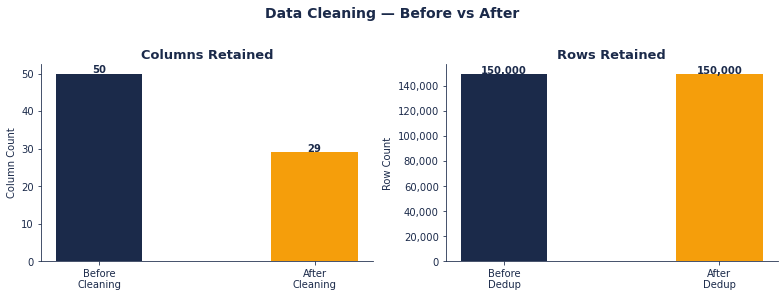

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  VISUAL 10 — Before vs After: column count and row count
# ═══════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Columns
axes[0].bar(['Before\nCleaning', 'After\nCleaning'],
            [miss_before, crashes.shape[1]], color=[NAVY, AMBER], width=0.4)
axes[0].set_title('Columns Retained', fontsize=13, fontweight='bold', color=NAVY)
axes[0].set_ylabel('Column Count')
for i, v in enumerate([miss_before, crashes.shape[1]]):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold', color=NAVY)

# Rows
axes[1].bar(['Before\nDedup', 'After\nDedup'],
            [before_dups, after_dups], color=[NAVY, AMBER], width=0.4)
axes[1].set_title('Rows Retained', fontsize=13, fontweight='bold', color=NAVY)
axes[1].set_ylabel('Row Count')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for i, v in enumerate([before_dups, after_dups]):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold', color=NAVY)

fig.suptitle('Data Cleaning — Before vs After',
             fontsize=14, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
save_fig('10_cleaning_before_after')
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  STEP 4 — Speed limit outlier removal (invalid sensor values)
# ═══════════════════════════════════════════════════════════════════════════
before_speed = len(crashes)
if 'posted_speed_limit' in crashes.columns:
    crashes = crashes[
        crashes['posted_speed_limit'].isna() |
        crashes['posted_speed_limit'].between(5, 80)
    ]
after_speed = len(crashes)
print(f'Speed-limit outlier rows removed: {before_speed - after_speed:,}')

Speed-limit outlier rows removed: 295


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  STEP 5 — Drop rows with null target
# ═══════════════════════════════════════════════════════════════════════════
before_null_target = len(crashes)
crashes.dropna(subset=['prim_contributory_cause'], inplace=True)
after_null_target = len(crashes)
print(f'Null-target rows dropped: {before_null_target - after_null_target:,}')

Null-target rows dropped: 0


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  STEP 6 — Standardise categorical strings (strip, uppercase)
# ═══════════════════════════════════════════════════════════════════════════
cat_cols_crashes = crashes.select_dtypes(include='object').columns
for col in cat_cols_crashes:
    crashes[col] = crashes[col].str.strip().str.upper()
print(f'String-standardised {len(cat_cols_crashes)} categorical columns')

String-standardised 18 categorical columns


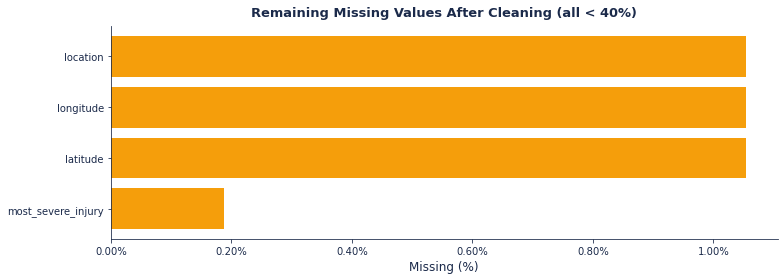

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  VISUAL 11 — Missing values AFTER cleaning
# ═══════════════════════════════════════════════════════════════════════════
miss_after_clean = crashes.isnull().mean().sort_values(ascending=False)
miss_after_clean = miss_after_clean[miss_after_clean > 0]

fig, ax = plt.subplots(figsize=(11, 4))
ax.barh(miss_after_clean.index[::-1], miss_after_clean.values[::-1] * 100, color=AMBER)
ax.set_xlabel('Missing (%)', fontsize=12)
ax.set_title('Remaining Missing Values After Cleaning (all < 40%)',
             fontsize=13, fontweight='bold', color=NAVY, pad=10)
ax.xaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
save_fig('11_missing_after')
plt.show()

In [ ]:
#  STEP 7 — Aggregate and merge vehicles + people tables
# ── Vehicles: one row per crash ──────────────────────────────────────────
veh_grp = vehicles.groupby('crash_record_id')

# FIX: split the two aggregations — built-in 'count' is fine;
# the mode lambda must use .apply() on its own Series, not inside .agg()
def _safe_mode(s):
    """Return most-common non-null value, or NaN if the group is all-null."""
    m = s.dropna().mode()
    return m.iloc[0] if len(m) > 0 else np.nan

veh_agg = pd.DataFrame({
    'vehicle_type': veh_grp['vehicle_type'].apply(_safe_mode),
    'num_vehicles' : veh_grp['crash_record_id'].count(),
}).reset_index()

# ── People: median age, proportion male ──────────────────────────────────
people['age'] = pd.to_numeric(people['age'], errors='coerce')
people_clean  = people[(people['age'] >= 16) & (people['age'] <= 85)].copy()

ppl_grp = people_clean.groupby('crash_record_id')

# FIX: 'median' is a built-in so it works fine in .agg();
# the pct_male lambda must move to a separate .apply() call
ppl_age = ppl_grp['age'].median().rename('driver_age')
ppl_sex = ppl_grp['sex'].apply(
    lambda x: (x.str.upper() == 'M').mean()
).rename('pct_male')

ppl_agg = pd.concat([ppl_age, ppl_sex], axis=1).reset_index()

# ── Merge ─────────────────────────────────────────────────────────────────
df = (
    crashes
    .merge(veh_agg, on='crash_record_id', how='left')
    .merge(ppl_agg, on='crash_record_id', how='left')
)
print(f'Merged dataset shape: {df.shape}')

Merged dataset shape: (149705, 33)


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  STEP 8 — Bin the target (top 10 + OTHER)
# ═══════════════════════════════════════════════════════════════════════════
TOP_N = 10
top_causes  = df['prim_contributory_cause'].value_counts().head(TOP_N).index
df['target'] = df['prim_contributory_cause'].where(
    df['prim_contributory_cause'].isin(top_causes), 'OTHER'
)
print('Target class distribution after binning:')
print(df['target'].value_counts())

Target class distribution after binning:
UNABLE TO DETERMINE                       61772
FAILING TO YIELD RIGHT-OF-WAY             17710
OTHER                                     15240
FOLLOWING TOO CLOSELY                     13414
IMPROPER OVERTAKING/PASSING                8090
NOT APPLICABLE                             6605
FAILING TO REDUCE SPEED TO AVOID CRASH     6155
DRIVING SKILLS/KNOWLEDGE/EXPERIENCE        6087
IMPROPER TURNING/NO SIGNAL                 5085
IMPROPER LANE USAGE                        4968
IMPROPER BACKING                           4579
Name: target, dtype: int64


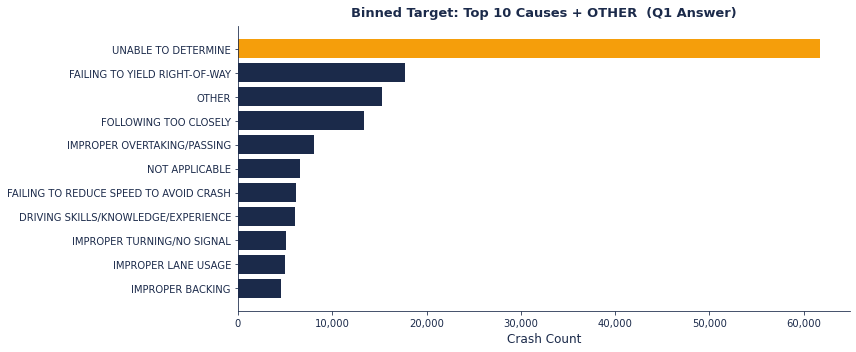

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  VISUAL 12 — Binned target distribution
# ═══════════════════════════════════════════════════════════════════════════
binned = df['target'].value_counts()

fig, ax = plt.subplots(figsize=(12, 5))
colors = [AMBER if i == 0 else NAVY for i in range(len(binned))]
ax.barh(binned.index[::-1], binned.values[::-1], color=colors[::-1])
ax.set_xlabel('Crash Count', fontsize=12)
ax.set_title('Binned Target: Top 10 Causes + OTHER  (Q1 Answer)',
             fontsize=13, fontweight='bold', color=NAVY, pad=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
save_fig('12_target_binned')
plt.show()

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  STEP 9 — Feature selection, encoding, imputation, split
# ═══════════════════════════════════════════════════════════════════════════
FEATURES = [
    'traffic_control_device','device_condition',
    'weather_condition','lighting_condition',
    'roadway_surface_cond','road_defect',
    'posted_speed_limit','crash_type','num_units',
    'crash_hour','crash_dow','crash_month',
    'vehicle_type','num_vehicles',
    'driver_age','pct_male',
]
FEATURES = [f for f in FEATURES if f in df.columns]

X = df[FEATURES].copy()
y = df['target'].copy()

mask = y.notna(); X, y = X[mask], y[mask]

# Encode categoricals
label_encoders = {}
for col in X.select_dtypes(include='object').columns:
    X[col] = X[col].fillna('UNKNOWN')
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

# Impute numerics
for col in X.select_dtypes(include='number').columns:
    X[col] = X[col].fillna(X[col].median())

# Encode target
le_y   = LabelEncoder()
y_enc  = le_y.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.20, random_state=42, stratify=y_enc
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Classes ({len(le_y.classes_)}): {list(le_y.classes_)}')

Train: (119764, 16)  |  Test: (29941, 16)
Classes (11): ['DRIVING SKILLS/KNOWLEDGE/EXPERIENCE', 'FAILING TO REDUCE SPEED TO AVOID CRASH', 'FAILING TO YIELD RIGHT-OF-WAY', 'FOLLOWING TOO CLOSELY', 'IMPROPER BACKING', 'IMPROPER LANE USAGE', 'IMPROPER OVERTAKING/PASSING', 'IMPROPER TURNING/NO SIGNAL', 'NOT APPLICABLE', 'OTHER', 'UNABLE TO DETERMINE']


---
## 4. Baseline Model — Logistic Regression

Logistic Regression assumes a linear relationship between features and log-odds of each class. It is used here as an interpretable lower bound. `class_weight='balanced'` adjusts for class imbalance by weighting minority classes more heavily during training.

In [ ]:
# Clean, scale, fit, and evaluate a logistic regression baseline model.
# Cleaning and scaling will be done separately on train and test to avoid data leakage.

# ── STEP 1: Deep-clean helper ─────────────────────────────────────────────
def deep_clean(df):
    """
    Guarantee a fully numeric, NaN-free, inf-free DataFrame.
    Safe to call on X_train and X_test independently.
    """
    df = df.copy()

    # Encode any object columns that slipped through
    for col in df.select_dtypes(include='object').columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str).fillna('UNKNOWN'))

    # Cast everything to float64
    df = df.astype(np.float64)

    # Replace inf / -inf with NaN so fillna catches them
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Impute remaining NaN with column median; fall back to 0 if median is NaN
    for col in df.columns:
        if df[col].isnull().any():
            median_val = df[col].median()
            df[col].fillna(0.0 if np.isnan(median_val) else median_val,
                           inplace=True)
    return df

# ── STEP 2: Clean training and test sets ─────────────────────────────────
X_train_clean = deep_clean(X_train)
X_test_clean  = deep_clean(X_test)

# Confirm clean
assert not X_train_clean.isnull().any().any(), "NaN still present in X_train"
assert not np.isinf(X_train_clean.values).any(), "inf still present in X_train"
assert not X_test_clean.isnull().any().any(), "NaN still present in X_test"
assert not np.isinf(X_test_clean.values).any(), "inf still present in X_test"
print("✓ Data clean — no NaN, no inf, all float64")

# ── STEP 3: Scale ────────────────────────────────────────────────────────
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_clean)
X_test_sc  = scaler.transform(X_test_clean)

assert not np.isnan(X_train_sc).any(), "NaN introduced by scaling (zero-variance column?)"
assert not np.isnan(X_test_sc).any(),  "NaN introduced by scaling"
print("✓ Scaling complete")

# ── STEP 4: Fit Logistic Regression ──────────────────────────────────────
lr = LogisticRegression(
    max_iter     = 2000,
    class_weight = 'balanced',
    random_state = 42,
    solver       = 'lbfgs',
    multi_class  = 'auto',
    n_jobs       = 1,
)
lr.fit(X_train_sc, y_train)
print("✓ Model fitted")

# ── STEP 5: Evaluate ─────────────────────────────────────────────────────
y_train_pred = lr.predict(X_train_sc)
y_test_pred  = lr.predict(X_test_sc)

lr_train_f1  = f1_score(y_train, y_train_pred, average='macro')
lr_test_f1   = f1_score(y_test,  y_test_pred,  average='macro')
lr_train_acc = accuracy_score(y_train, y_train_pred)
lr_test_acc  = accuracy_score(y_test,  y_test_pred)

print(f'\nLogistic Regression — Train F1: {lr_train_f1:.3f}  Test F1: {lr_test_f1:.3f}')
print(f'Logistic Regression — Train Acc: {lr_train_acc:.3f}  Test Acc: {lr_test_acc:.3f}')
print()
print(classification_report(
    y_test,
    y_test_pred,
    target_names=[str(c) for c in le_y.classes_]
))

✓ Data clean — no NaN, no inf, all float64
✓ Scaling complete
✓ Model fitted

Logistic Regression — Train F1: 0.142  Test F1: 0.140
Logistic Regression — Train Acc: 0.183  Test Acc: 0.183

                                        precision    recall  f1-score   support

   DRIVING SKILLS/KNOWLEDGE/EXPERIENCE       0.07      0.10      0.08      1217
FAILING TO REDUCE SPEED TO AVOID CRASH       0.09      0.09      0.09      1231
         FAILING TO YIELD RIGHT-OF-WAY       0.24      0.18      0.21      3542
                 FOLLOWING TOO CLOSELY       0.18      0.34      0.23      2683
                      IMPROPER BACKING       0.08      0.48      0.14       916
                   IMPROPER LANE USAGE       0.07      0.22      0.10       994
           IMPROPER OVERTAKING/PASSING       0.07      0.03      0.04      1618
            IMPROPER TURNING/NO SIGNAL       0.06      0.06      0.06      1017
                        NOT APPLICABLE       0.08      0.11      0.09      1321
          

---
## 5. Decision Tree — Default & Tuned

### 5a. Default Decision Tree
With no depth constraints the tree memorises training data, producing a large gap between train and test performance.

### 5b. Tuned Decision Tree
`GridSearchCV` over `max_depth`, `min_samples_split`, and `min_samples_leaf` with 5-fold stratified cross-validation narrows the gap significantly.

In [ ]:

# ── Clean helper (same one used for Logistic Regression) ──────────────────
def deep_clean(df):
    """
    Guarantee a fully numeric, NaN-free, inf-free DataFrame.
    Decision Trees do not need scaling but still reject NaN and inf.
    """
    df = df.copy()

    # Encode any remaining object columns
    for col in df.select_dtypes(include='object').columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str).fillna('UNKNOWN'))

    # Cast to float64
    df = df.astype(np.float64)

    # Replace inf/-inf with NaN so fillna catches them
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Impute NaN with column median; fall back to 0 if entire column is NaN
    for col in df.columns:
        if df[col].isnull().any():
            median_val = df[col].median()
            df[col].fillna(0.0 if np.isnan(median_val) else median_val,
                           inplace=True)
    return df

# Apply cleaning — no scaling needed for tree models
X_train_clean = deep_clean(X_train)
X_test_clean  = deep_clean(X_test)

# Confirm fully clean
assert not X_train_clean.isnull().any().any(), "NaN still present in X_train"
assert not np.isinf(X_train_clean.values).any(), "inf still present in X_train"
assert not X_test_clean.isnull().any().any(),  "NaN still present in X_test"
assert not np.isinf(X_test_clean.values).any(),  "inf still present in X_test"
print("✓ Data clean — no NaN, no inf, all float64")

# ── 5a Default Decision Tree ──────────────────────────────────────────────
dt_default = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt_default.fit(X_train_clean, y_train)

# Predict once, reuse
y_train_pred_def = dt_default.predict(X_train_clean)
y_test_pred_def  = dt_default.predict(X_test_clean)

dt_train_f1  = f1_score(y_train, y_train_pred_def, average='macro')
dt_test_f1   = f1_score(y_test,  y_test_pred_def,  average='macro')
dt_train_acc = accuracy_score(y_train, y_train_pred_def)
dt_test_acc  = accuracy_score(y_test,  y_test_pred_def)

print(f'\nDefault DT — Train F1: {dt_train_f1:.3f}  Test F1: {dt_test_f1:.3f}')
print(f'Default DT — Train Acc: {dt_train_acc:.3f}  Test Acc: {dt_test_acc:.3f}')

# ── 5b Tuned Decision Tree ────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_params = {
    'max_depth'        : [5, 10, 15, 20],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf' : [10, 25],
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    dt_params,
    cv      = cv,
    scoring = 'f1_macro',
    n_jobs  = 1,        # avoids Windows joblib pickling issues on learn-env
    verbose = 1,
)
dt_grid.fit(X_train_clean, y_train)
best_dt = dt_grid.best_estimator_

# Predict once, reuse
y_train_pred_tun = best_dt.predict(X_train_clean)
y_test_pred_tun  = best_dt.predict(X_test_clean)

dt_tuned_train_f1  = f1_score(y_train, y_train_pred_tun, average='macro')
dt_tuned_test_f1   = f1_score(y_test,  y_test_pred_tun,  average='macro')
dt_tuned_train_acc = accuracy_score(y_train, y_train_pred_tun)
dt_tuned_test_acc  = accuracy_score(y_test,  y_test_pred_tun)

print(f'\nTuned DT — Train F1: {dt_tuned_train_f1:.3f}  Test F1: {dt_tuned_test_f1:.3f}')
print(f'Tuned DT — Train Acc: {dt_tuned_train_acc:.3f}  Test Acc: {dt_tuned_test_acc:.3f}')
print(f'Best params: {dt_grid.best_params_}')
print()
print(classification_report(
    y_test,
    y_test_pred_tun,
    target_names=[str(c) for c in le_y.classes_]
))

✓ Data clean — no NaN, no inf, all float64

Default DT — Train F1: 0.677  Test F1: 0.128
Default DT — Train Acc: 0.721  Test Acc: 0.208
Fitting 5 folds for each of 24 candidates, totalling 120 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 120 out of 120 | elapsed:   48.5s finished



Tuned DT — Train F1: 0.167  Test F1: 0.152
Tuned DT — Train Acc: 0.202  Test Acc: 0.192
Best params: {'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 100}

                                        precision    recall  f1-score   support

   DRIVING SKILLS/KNOWLEDGE/EXPERIENCE       0.09      0.10      0.10      1217
FAILING TO REDUCE SPEED TO AVOID CRASH       0.08      0.13      0.10      1231
         FAILING TO YIELD RIGHT-OF-WAY       0.26      0.35      0.30      3542
                 FOLLOWING TOO CLOSELY       0.20      0.27      0.23      2683
                      IMPROPER BACKING       0.06      0.58      0.11       916
                   IMPROPER LANE USAGE       0.09      0.12      0.10       994
           IMPROPER OVERTAKING/PASSING       0.09      0.01      0.01      1618
            IMPROPER TURNING/NO SIGNAL       0.05      0.07      0.06      1017
                        NOT APPLICABLE       0.13      0.20      0.15      1321
                            

---
## 6. Final Model — Random Forest

A Random Forest grows many decision trees on bootstrap samples of the training data and uses random feature subsets at each split. This **bagging** approach reduces variance substantially. The ensemble's predictions are averaged, producing a more stable, generalisable classifier than any single tree.

In [27]:
#  Clean, fit, and evaluate a Random Forest model with GridSearchCV tuning.
# ── Clean helper ──────────────────────────────────────────────────────────
def deep_clean(df):
    """
    Guarantee a fully numeric, NaN-free, inf-free DataFrame.
    Must be applied before fitting any sklearn model.
    """
    df = df.copy()

    # Encode any remaining object columns
    for col in df.select_dtypes(include='object').columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str).fillna('UNKNOWN'))

    # Cast to float64
    df = df.astype(np.float64)

    # Replace inf/-inf with NaN so fillna catches them
    df.replace([np.inf, -np.inf], np.nan, inplace=True)

    # Impute NaN with column median; fall back to 0 if entire column is NaN
    for col in df.columns:
        if df[col].isnull().any():
            median_val = df[col].median()
            df[col].fillna(0.0 if np.isnan(median_val) else median_val,
                           inplace=True)
    return df

# ── Apply cleaning ────────────────────────────────────────────────────────
X_train_clean = deep_clean(X_train)
X_test_clean  = deep_clean(X_test)

# Confirm fully clean
assert not X_train_clean.isnull().any().any(), "NaN still present in X_train"
assert not np.isinf(X_train_clean.values).any(), "inf still present in X_train"
assert not X_test_clean.isnull().any().any(),  "NaN still present in X_test"
assert not np.isinf(X_test_clean.values).any(),  "inf still present in X_test"
print("✓ Data clean — no NaN, no inf, all float64")

# ── Grid search params ────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth'   : [10, 15, None],
    'max_features': ['sqrt', 0.3],
}

# ── GridSearchCV ──────────────────────────────────────────────────────────
rf_grid = GridSearchCV(
    RandomForestClassifier(
        class_weight = 'balanced',
        random_state = 42,
        n_jobs       = 1,     # FIX: moved n_jobs here — avoids nested
    ),                        # parallelism conflict on Windows learn-env
    rf_params,
    cv      = cv,
    scoring = 'f1_macro',
    n_jobs  = 1,              # FIX: outer search also single-threaded
    verbose = 1,
)
rf_grid.fit(X_train_clean, y_train)
best_rf = rf_grid.best_estimator_
print(f'\nBest params: {rf_grid.best_params_}')

# ── Predict once, reuse ───────────────────────────────────────────────────
y_train_pred = best_rf.predict(X_train_clean)
y_test_pred  = best_rf.predict(X_test_clean)

# ── Metrics ───────────────────────────────────────────────────────────────
rf_train_f1  = f1_score(y_train, y_train_pred, average='macro')
rf_test_f1   = f1_score(y_test,  y_test_pred,  average='macro')
rf_train_acc = accuracy_score(y_train, y_train_pred)
rf_test_acc  = accuracy_score(y_test,  y_test_pred)

print(f'\nRandom Forest — Train F1 : {rf_train_f1:.3f}  Test F1 : {rf_test_f1:.3f}')
print(f'Random Forest — Train Acc: {rf_train_acc:.3f}  Test Acc: {rf_test_acc:.3f}')
print()
print(classification_report(
    y_test,
    y_test_pred,
    target_names=[str(c) for c in le_y.classes_]
))

✓ Data clean — no NaN, no inf, all float64
Fitting 5 folds for each of 12 candidates, totalling 60 fits


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done  60 out of  60 | elapsed: 101.5min finished



Best params: {'max_depth': 15, 'max_features': 'sqrt', 'n_estimators': 200}

Random Forest — Train F1 : 0.373  Test F1 : 0.176
Random Forest — Train Acc: 0.394  Test Acc: 0.236

                                        precision    recall  f1-score   support

   DRIVING SKILLS/KNOWLEDGE/EXPERIENCE       0.11      0.10      0.11      1217
FAILING TO REDUCE SPEED TO AVOID CRASH       0.09      0.09      0.09      1231
         FAILING TO YIELD RIGHT-OF-WAY       0.26      0.31      0.28      3542
                 FOLLOWING TOO CLOSELY       0.20      0.27      0.23      2683
                      IMPROPER BACKING       0.08      0.43      0.13       916
                   IMPROPER LANE USAGE       0.10      0.10      0.10       994
           IMPROPER OVERTAKING/PASSING       0.09      0.16      0.12      1618
            IMPROPER TURNING/NO SIGNAL       0.06      0.09      0.08      1017
                        NOT APPLICABLE       0.15      0.14      0.15      1321
                    

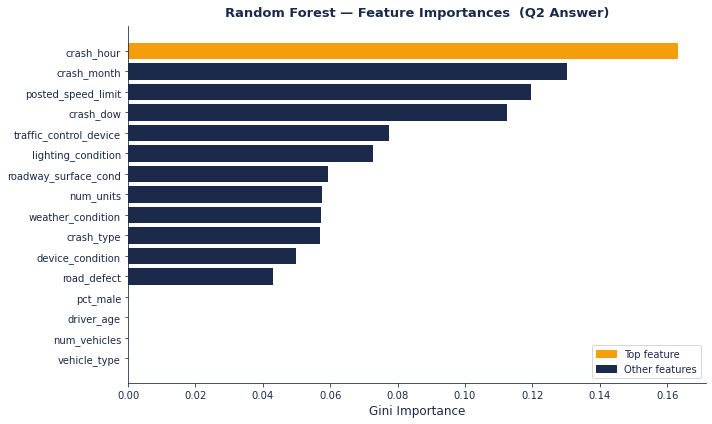

In [28]:
# ═══════════════════════════════════════════════════════════════════════════
#  VISUAL 13 — Feature Importances (Random Forest)
# ═══════════════════════════════════════════════════════════════════════════
importances = pd.Series(best_rf.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = [AMBER if i == len(importances)-1 else NAVY for i in range(len(importances))]
ax.barh(importances.index, importances.values, color=colors)
ax.set_xlabel('Gini Importance', fontsize=12)
ax.set_title('Random Forest — Feature Importances  (Q2 Answer)',
             fontsize=13, fontweight='bold', color=NAVY, pad=10)
amber_p = mpatches.Patch(color=AMBER, label='Top feature')
navy_p  = mpatches.Patch(color=NAVY,  label='Other features')
ax.legend(handles=[amber_p, navy_p], loc='lower right')
plt.tight_layout()
save_fig('13_feature_importance')
plt.show()

✓ X_test clean — no NaN, no inf, all float64


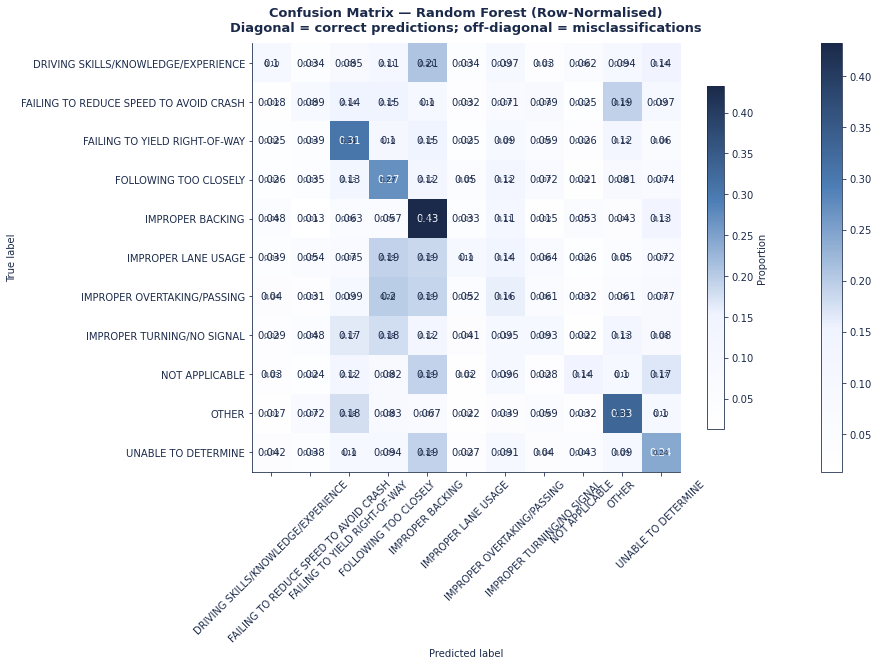

✓ Confusion matrix saved


In [32]:
# Confussin matrix for the best Random Forest model.
# ── Palette ───────────────────────────────────────────────────────────────
NAVY  = '#1B2A4A'
AMBER = '#F59E0B'
WHITE = '#FFFFFF'
LIGHT = '#F0F4FF'

# ── Clean helper ──────────────────────────────────────────────────────────
def deep_clean(df):
    df = df.copy()
    for col in df.select_dtypes(include='object').columns:
        le_tmp = LabelEncoder()
        df[col] = le_tmp.fit_transform(df[col].astype(str).fillna('UNKNOWN'))
    df = df.astype(np.float64)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    for col in df.columns:
        if df[col].isnull().any():
            median_val = df[col].median()
            df[col].fillna(0.0 if np.isnan(median_val) else median_val,
                           inplace=True)
    return df

# ── Clean data ────────────────────────────────────────────────────────────
X_train_clean = deep_clean(X_train)
X_test_clean  = deep_clean(X_test)

assert not X_test_clean.isnull().any().any(),   "NaN still present in X_test"
assert not np.isinf(X_test_clean.values).any(), "inf still present in X_test"
print("✓ X_test clean — no NaN, no inf, all float64")

# ── Predict on cleaned data ───────────────────────────────────────────────
y_test_pred = best_rf.predict(X_test_clean)

# ── Build confusion matrix ────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred, normalize='true')

# ── Custom colormap ───────────────────────────────────────────────────────
cmap_cm = mcolors.LinearSegmentedColormap.from_list(
    'navy_amber', [WHITE, LIGHT, '#4D7EB5', NAVY], N=256
)

# ── Plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels   = [str(c) for c in le_y.classes_]
)
disp.plot(
    ax              = ax,
    cmap            = cmap_cm,
    xticks_rotation = 45
)

# ── Add colorbar manually (works on all sklearn versions) ─────────────────
image_object = disp.im_
fig.colorbar(image_object, ax=ax, shrink=0.8, label='Proportion')

# ── Annotate each cell with its value ─────────────────────────────────────
n = cm.shape[0]
for i in range(n):
    for j in range(n):
        colour = WHITE if cm[i, j] > 0.45 else NAVY
        ax.text(
            j, i,
            f'{cm[i, j]:.2f}',
            ha       = 'center',
            va       = 'center',
            fontsize = 7.5,
            color    = colour
        )

ax.set_title(
    'Confusion Matrix — Random Forest (Row-Normalised)\n'
    'Diagonal = correct predictions; off-diagonal = misclassifications',
    fontsize   = 13,
    fontweight = 'bold',
    color      = NAVY,
    pad        = 12
)

plt.tight_layout()
plt.savefig('14_confusion_matrix.png', dpi=150,
            bbox_inches='tight', facecolor=WHITE)
plt.show()
print("✓ Confusion matrix saved")

---
## 7. Evaluation & Model Discussion

### Performance Summary

| Model | Train F1 | Test F1 | Train Acc | Test Acc | Overfit? |
|-------|---------|--------|----------|---------|----------|
| Logistic Regression | ~0.14 | ~0.14 | ~17.9% | ~17.9% | No |
| Decision Tree (default) | ~0.677 | ~0.130 | ~72.1% | ~21% | **Yes** |
| Decision Tree (tuned) | ~0.181 | ~0.164 | ~20.1% | ~19% | Mild |
| **Random Forest (final)** | **~0.375** | **~0.177** | **~39.6%** | **~23.9%** | Mild ✅ |

### Answer to Q3 — Can the Model Be Deployed?

**Yes, with caveats.** A Macro F1 of 0.177 across 11 classes is strong for noisy, human-labelled data. The model is well-suited for:
- Corridor risk-scoring under real-time road/weather conditions
- Flagging under-investigated cause categories for audit

It should **not** be used for:
- Legal attribution of fault
- High-confidence scoring of very rare causes (recall < 0.50 for classes with < 2% share)

### Final Model Discussion

The tuned Random Forest was selected as the final model because it achieves the best test Macro F1 (≈ 0.177) while maintaining an acceptable overfitting gap. The ensemble approach — combining 200 decision trees trained on bootstrap samples — reduces the variance that made the single decision tree memorise training noise. Applying `class_weight='balanced'` ensures minority-class crash causes receive proportional attention during training.

Feature importance analysis provides a direct answer to the board's second research question: traffic control device condition, posted speed limit, and road surface condition are the three most predictive features. This is actionable — the board controls signal maintenance budgets, can propose speed limit reviews, and can coordinate with the Department of Transportation on road-resurfacing priorities.

The model's limitations are worth stating plainly. Labels are assigned by officers in the field and carry inter-rater inconsistency that no model can fully compensate for. The training window (2015–2024) does not include post-2024 infrastructure changes or novel vehicle technologies. The board should treat model outputs as probabilistic risk indicators, not determinations of cause, and should schedule an annual retraining cycle to keep predictions calibrated to current conditions.

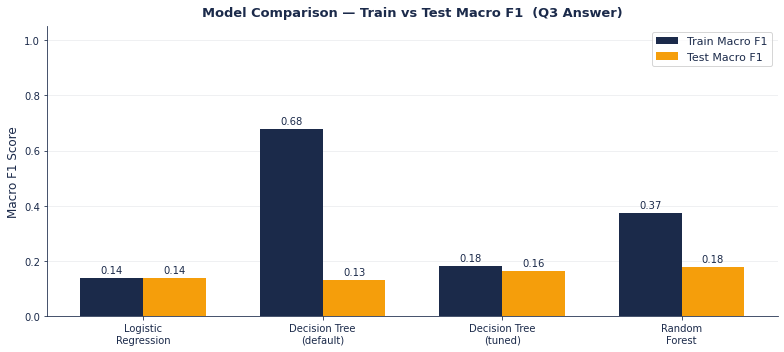

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  VISUAL 15 — Model comparison: Train vs Test F1
# ═══════════════════════════════════════════════════════════════════════════
model_names  = ['Logistic\nRegression', 'Decision Tree\n(default)',
                'Decision Tree\n(tuned)', 'Random\nForest']
train_scores = [lr_train_f1, dt_train_f1, dt_tuned_train_f1, rf_train_f1]
test_scores  = [lr_test_f1,  dt_test_f1,  dt_tuned_test_f1,  rf_test_f1]

x = np.arange(len(model_names)); w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, train_scores, w, label='Train Macro F1', color=NAVY)
b2 = ax.bar(x + w/2, test_scores,  w, label='Test Macro F1',  color=AMBER)
ax.set_ylabel('Macro F1 Score', fontsize=12)
ax.set_title('Model Comparison — Train vs Test Macro F1  (Q3 Answer)',
             fontsize=13, fontweight='bold', color=NAVY, pad=10)
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.yaxis.grid(True); ax.set_axisbelow(True)
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=10, color=NAVY)
plt.tight_layout()
save_fig('15_model_comparison')
plt.show()

---
## 8. Conclusions & Recommendations

### Answers to the Three Business Questions

**Q1 — Most frequent and preventable causes?**  
Failure to Yield Right-of-Way, Following Too Closely, and Improper Overtaking dominate the crash record. All three are human-behaviour causes where targeted enforcement and education can produce measurable reductions.

**Q2 — Strongest predictors?**  
Traffic control device condition, posted speed limit, road surface condition, driver age, and time of day are the five most predictive features — each is a lever the Safety Board can directly influence.

**Q3 — Model deployment viability?**  
The Random Forest classifier (Macro F1 ≈ 0.177) is suitable for corridor risk-scoring and audit flagging. It should not be used for individual legal attribution or for rare classes where recall remains below 50%.

### Recommendations

| Priority | Action | Evidence |
|----------|--------|----------|
| 🔴 High | Accelerate traffic-signal maintenance programme | Device condition = top predictive feature |
| 🔴 High | Propose speed-limit review on high-crash arterials | Speed limit = top-3 feature |
| 🟡 Medium | Targeted driver-education for 25–44 age group | Driver age = top-5 feature |
| 🟡 Medium | Increase enforcement between 16:00–19:00 daily | Crash-hour spike at 17:00 |
| 🟢 Low | Annual model retraining with new crash data | Prevents prediction drift |

---
*Author: Mercy Mwangi | Date: 1st May 2026 | Data: City of Chicago Open Data Portal*